In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from PIL import Image  # For GIF creation
import os
import warnings

import numpy as np
import pandas as pd
import skimage
import torch

import neuralpredictors

warnings.filterwarnings("ignore")

from nnfabrik.builder import get_data, get_model, get_trainer
from nnfabrik.utility.nn_helpers import set_random_seed


In [2]:
seed = 42
set_random_seed(seed)

starting_epcoch = 30
multiplier = 4000000000.0
exponent=2
clusters=2
path_ending = 'without_KL_seed_42'
model = torch.load(path_ending)

FileNotFoundError: [Errno 2] No such file or directory: 'without_KL_seed_42'

In [ ]:
features_list = []  # List to store features
features_shape_previous = 0
i = 0

for k, readout in model.readout.items():
    # Extract features and their shape
    features = readout.features.cpu().detach().squeeze().T.numpy()
    features_list.append(features)  # Append the full features to the list

features_list = np.vstack(features_list)
random_indices_predicted = np.load("random_indices_predicted.npy")
combined_features = features_list[random_indices_predicted]
n = combined_features.shape[0]

In [ ]:
all_features = np.vstack(features_list)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
normalized_features = scaler.fit_transform(all_features)

# Single color plot without cluster centers

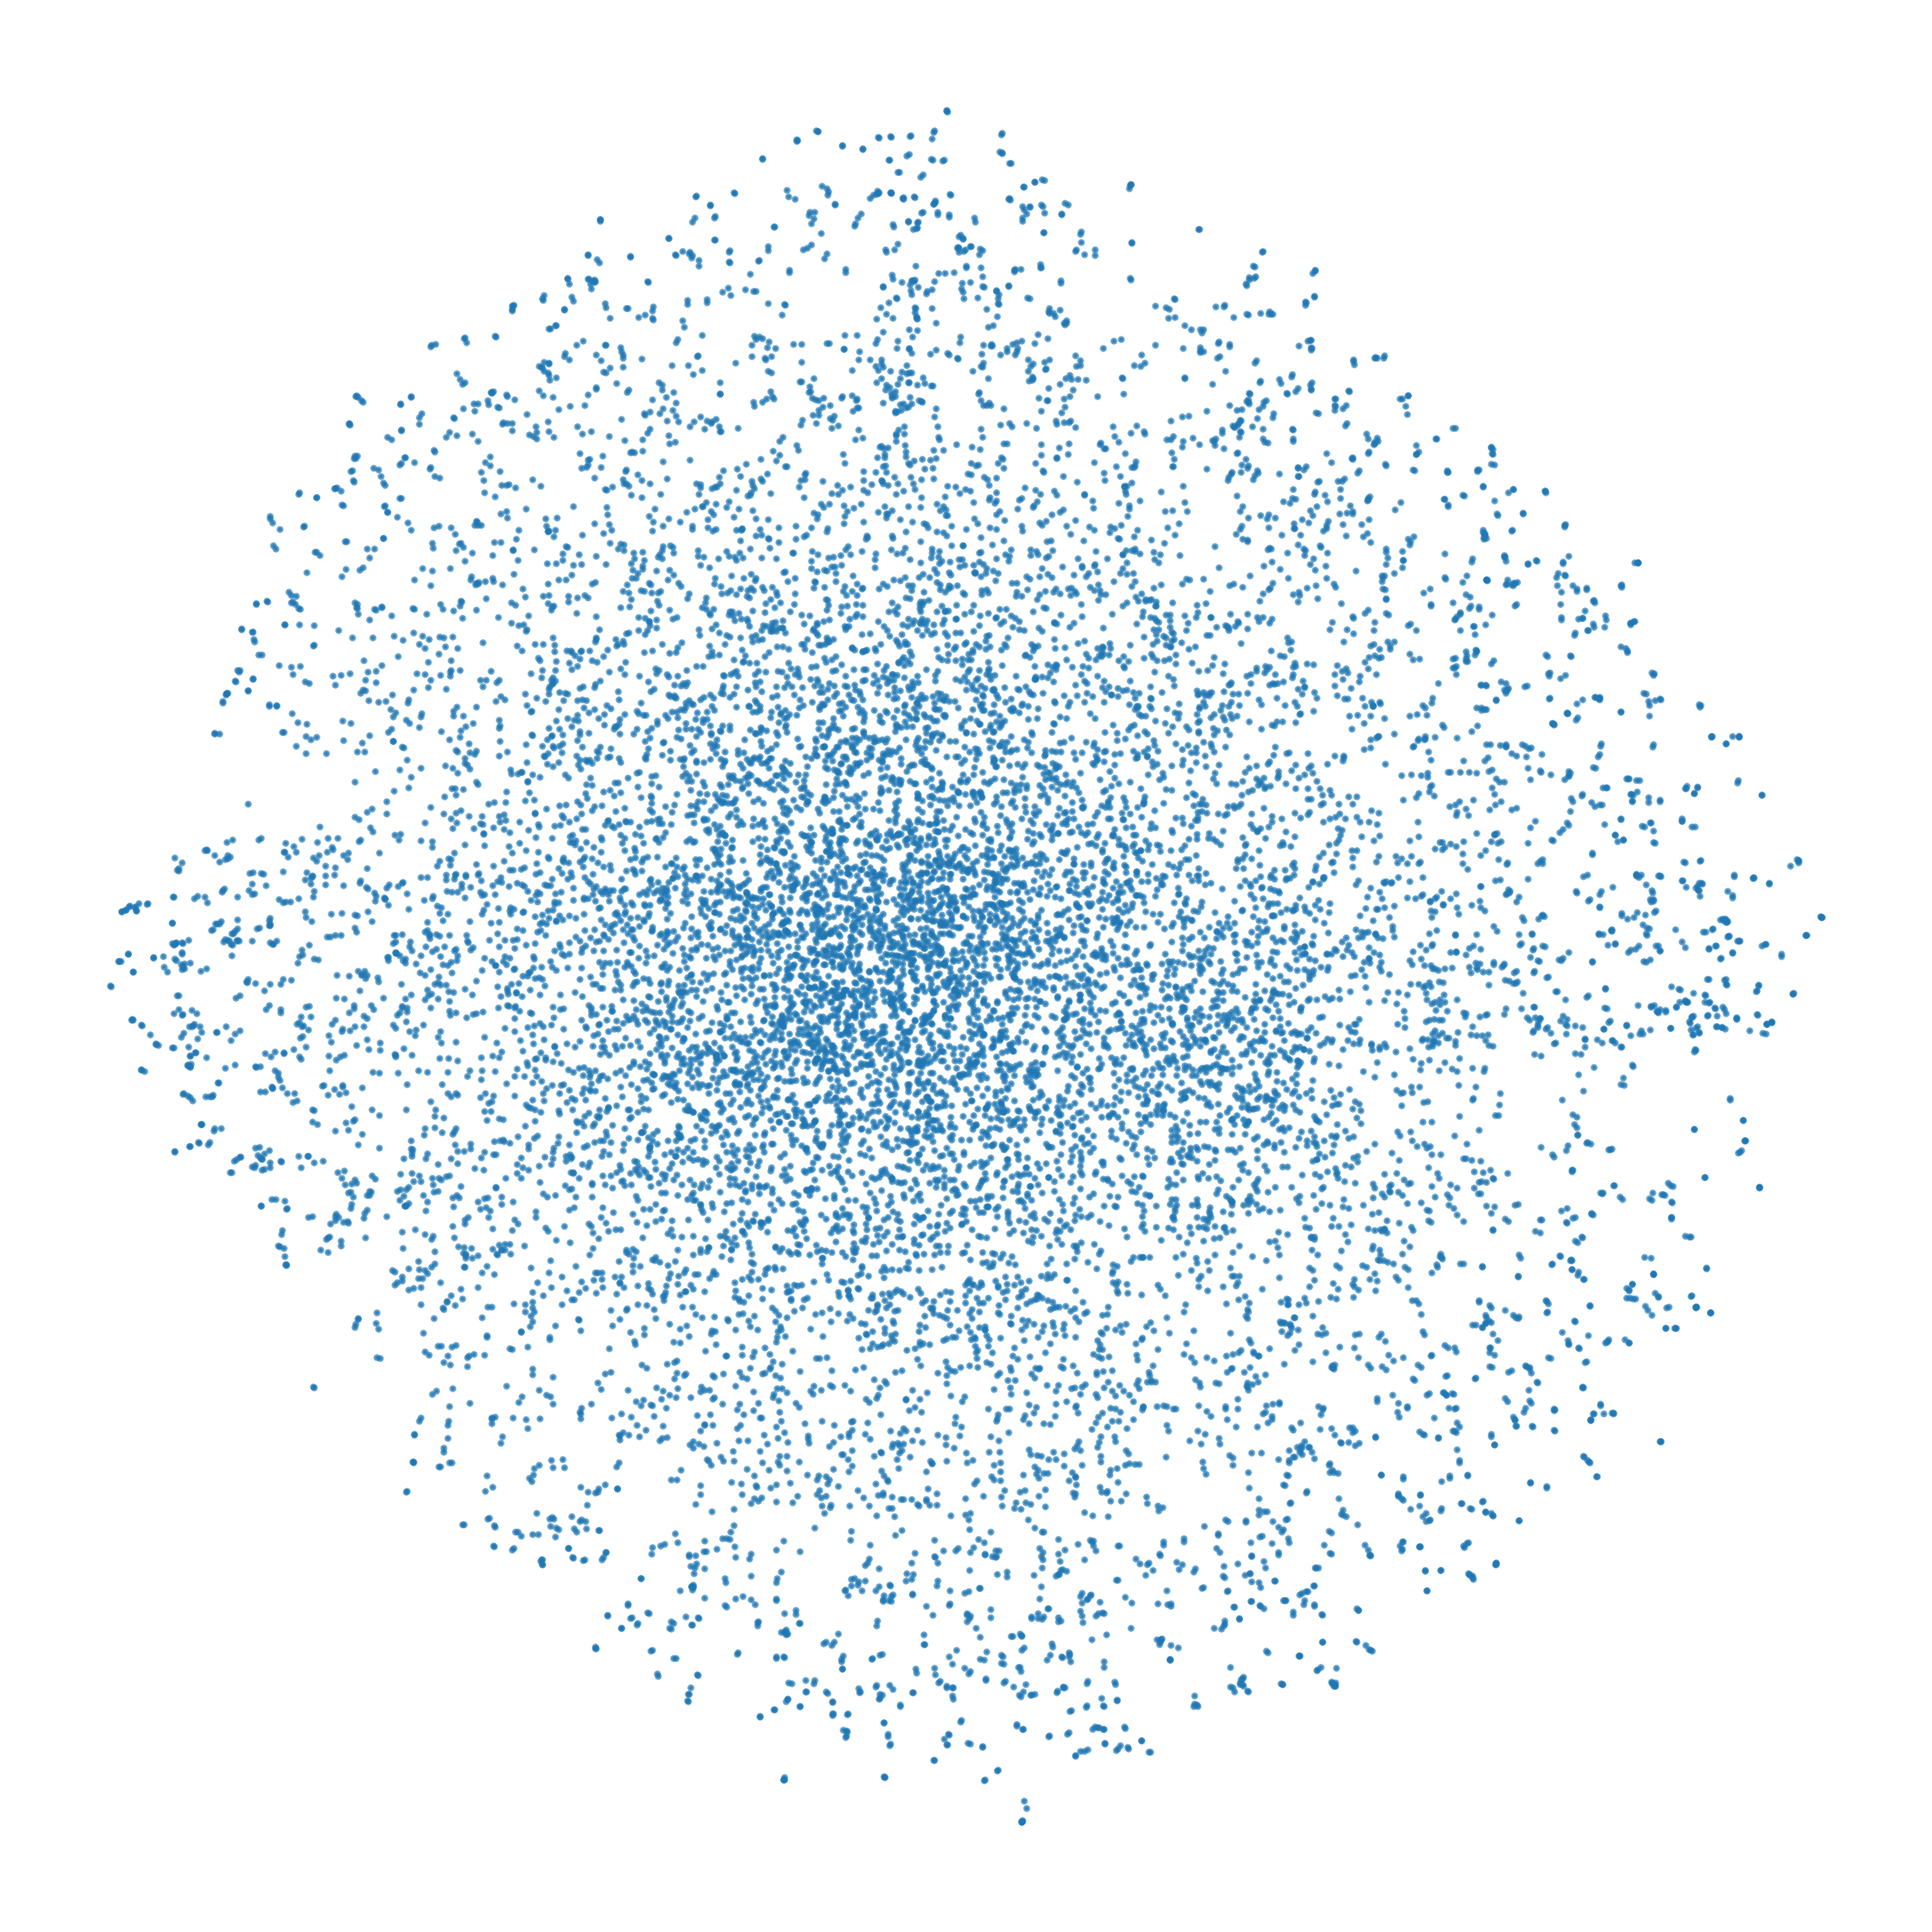

In [ ]:
plt.figure(figsize=(8,8), dpi=300)  # Create a single figure
perplexity = n / 100
lr = 1
early_exaggeration = n/10

tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, early_exaggeration=early_exaggeration, random_state=42)
embedded_points = tsne.fit_transform(combined_features)  # Run on unnormalized data

single_color="#1f77b4"

plt.scatter(
    embedded_points[:, 0], embedded_points[:, 1],
    c=single_color, alpha=0.7, s=1
)

plt.xticks([])  # Remove x ticks
plt.yticks([])  # Remove y ticks
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.tight_layout()
plt.show()